# 01 — Exploratory Data Analysis

**Network Intrusion Detection** — understanding the data before modelling.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/network_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 11)


,duration,protocol_type,src_bytes,dst_bytes,count,srv_count,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,label
0,2.397368,tcp,6374.876419,2201.551498,9,10,0.937207,0.007748,93,192,normal
1,0.053518,icmp,16892.272248,92.198748,216,2,0.106043,0.872184,10,4,attack
2,0.109308,icmp,46114.178988,14.265435,245,4,0.032784,0.715903,13,8,attack
3,2.201034,icmp,4895.550781,4399.667123,26,15,0.742598,0.089573,107,51,normal
4,14.984862,tcp,7558.199286,3369.738133,19,14,0.990341,0.041914,102,236,normal


In [4]:
print(df['label'].value_counts())
print(f'\nAttack rate: {(df.label=="attack").mean()*100:.1f}%')

label
normal    700
attack    300
Name: count, dtype: int64

Attack rate: 30.0%


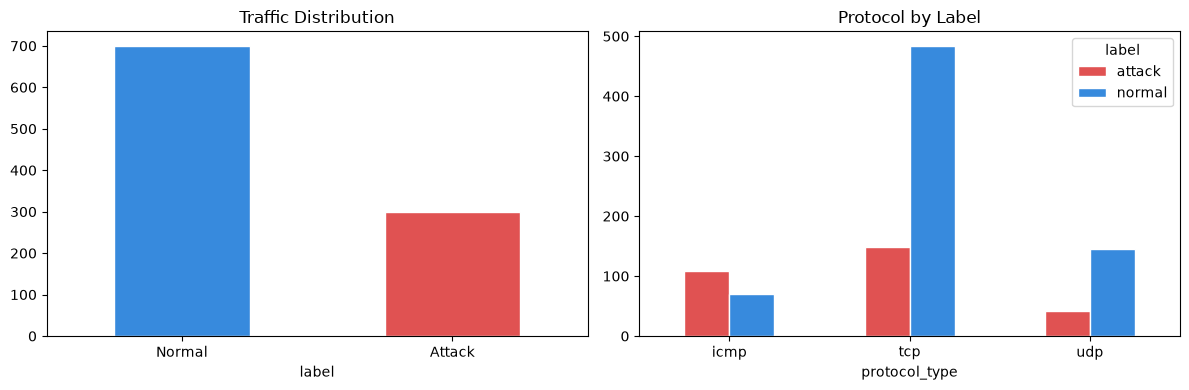

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#378ADD','#E05252'], edgecolor='white')
axes[0].set_title('Traffic Distribution')
axes[0].set_xticklabels(['Normal','Attack'], rotation=0)

pd.crosstab(df['protocol_type'], df['label']).plot(kind='bar', ax=axes[1], color=['#E05252','#378ADD'], edgecolor='white')
axes[1].set_title('Protocol by Label')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

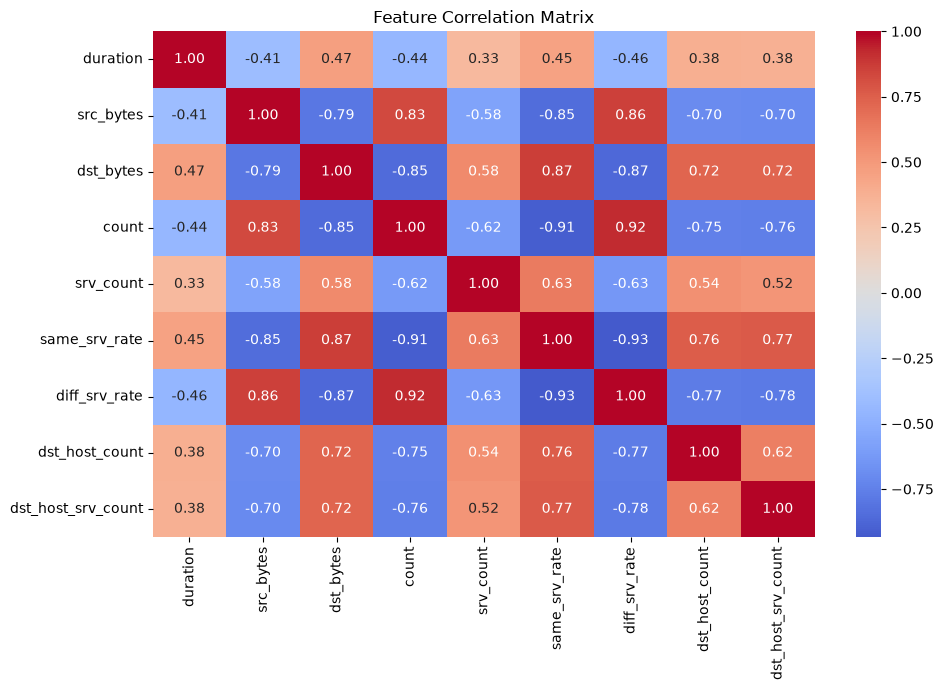

In [6]:
numeric = df.select_dtypes(include='number')
plt.figure(figsize=(10,7))
sns.heatmap(numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

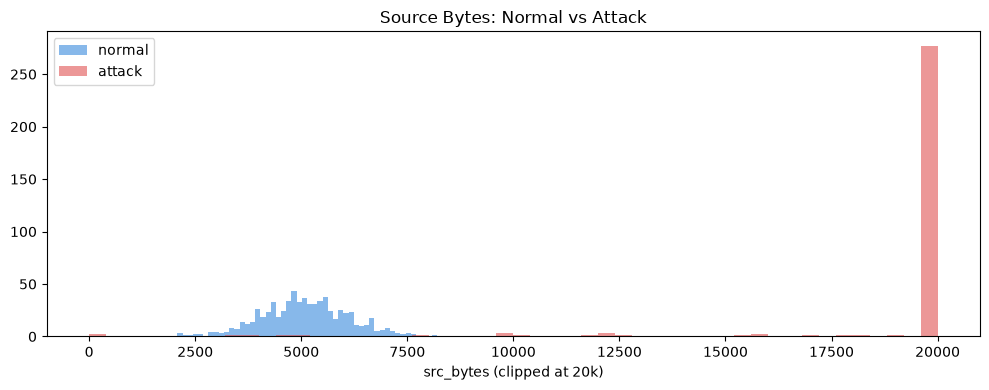

In [7]:
fig, ax = plt.subplots(figsize=(10,4))
for label, color in [('normal','#378ADD'),('attack','#E05252')]:
    ax.hist(df[df.label==label]['src_bytes'].clip(0,20000), bins=50, alpha=0.6, label=label, color=color)
ax.set_title('Source Bytes: Normal vs Attack')
ax.set_xlabel('src_bytes (clipped at 20k)')
ax.legend()
plt.tight_layout()
plt.show()

## Key Observations
- Attack traffic has **much higher `src_bytes`** — floods / exfiltration
- Attack `count` spikes near 512 — port scan signature
- `diff_srv_rate` higher for attacks — lateral movement patterns
- **icmp** more common in attacks — ICMP flood